# Shannon Diversity vs Timepoint (Recalled Genera)

Updated version of the Shannon diversity vs timepoint plot from `Local_analysis/Transcriptome_vs_weather_and_microbiome/Time_and_rain_correlation/bacteria_vs_transcriptome_time_abundance_rain_correlation_plates_1_to_5.ipynb`, using the recalled-genera table (`lic_16S_gen_rab_clean.csv`). It uses the seasonal plant samples only, t01–t28.

Differences from the original calculation:
- Genera absent from a sample count as 0 when averaging within a timepoint. The original averaged only over the samples where a genus was present.
- The timepoint-averaged abundances are normalised to proportions that sum to 1 before computing Shannon.

A second plot shows the per-sample Shannon values provided alongside the new table (`lic_16S_gen_shannon.csv`) as a cross-check.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
def calculate_shannon_diversity_from_proportions(abundance_array):
    """Calculate Shannon diversity index from an array of proportions."""
    # Filter out zero proportions to avoid log(0)
    filtered_abundance = abundance_array[abundance_array > 0]
    shannon_index = -np.sum(filtered_abundance * np.log(filtered_abundance))
    return shannon_index

In [3]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Sept_2026_recalled_genera/lic_16S_gen_rab_clean.csv"
)
long_term_microbiome = microbiome_abundance.loc[
    (microbiome_abundance["sample.type"] == "plant")
    & (microbiome_abundance["seascirc"] == "seasonal")
]
print("samples:", long_term_microbiome["Sample"].nunique())
print("timepoints:", long_term_microbiome["timepoint"].nunique())

samples: 222
timepoints: 28


In [4]:
# Sample x genus matrix (absent genera = 0), then mean abundance per timepoint
sample_genus_matrix = pd.pivot_table(
    long_term_microbiome,
    values="Abundance",
    index="Sample",
    columns="Genus",
    aggfunc="sum",
    fill_value=0,
)
sample_timepoint = long_term_microbiome.groupby("Sample")["timepoint"].first()

all_genus_abundance_matrix = sample_genus_matrix.groupby(sample_timepoint).mean()
all_genus_abundance_matrix

Genus,c__Dehalococcoidia Class,f__Bryobacteraceae Family,f__Burkholderiaceae_A_595421 Family,f__Gaiellaceae Family,f__Ilumatobacteraceae Family,f__Methylophilaceae Family,f__Micropepsaceae Family,f__Microtrichaceae Family,f__Nocardioidaceae Family,f__Pyrinomonadaceae Family,...,g__WQYW01,g__WRKR01,g__Weizmannia,g__Williamsia,g__X156,g__Xanthomonas,g__Xenophilus,g__Z2-YC6860,g__Zeimonas,o__UBA5066 Order
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,0.272494,0.117104,4.628781,0.000000,0.000000,0.000000,0.155773,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.376710,0.000000,0.000000,0.000000,0.000000,0.151105,0.192568
t02,0.486749,0.171319,12.511576,0.000000,0.000000,0.000000,0.376052,0.065841,0.000000,0.000000,...,0.150682,0.081368,0.000000,1.516957,0.000000,0.298283,0.000000,0.000000,0.190134,0.328672
t03,0.065837,0.000000,7.057171,0.000000,0.000000,0.000000,0.114956,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.372544,0.000000,0.000000,0.000000,0.086253,0.176818,0.000000
t04,0.479884,0.158303,3.807054,0.000000,0.000000,0.000000,0.287732,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.514001,0.000000,0.000000,0.000000,0.191159,0.262199,0.000000
t05,0.680196,0.000000,6.705846,0.000000,0.000000,0.000000,0.000000,0.115163,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.854450,0.000000,1.168861,0.000000,0.000000,0.314595,0.000000
t06,0.233308,0.062568,8.414217,0.000000,0.000000,0.000000,0.284714,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.200769,0.000000,0.000000,0.000000,0.000000,0.121588,0.000000
t07,0.158116,0.099831,19.737564,0.148381,0.000000,0.000000,0.110924,0.066772,0.000000,0.000000,...,0.000000,0.000000,0.072100,0.240499,0.000000,0.112982,0.000000,0.000000,0.135162,0.000000
t08,0.000000,0.000000,21.251199,0.000000,0.000000,0.000000,0.064480,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.702342,0.000000,0.000000,0.000000,0.000000,0.177497,0.000000
t09,0.303525,0.080593,34.915958,0.172340,0.000000,0.000000,0.086170,0.000000,0.532495,0.000000,...,0.000000,0.000000,0.000000,0.378494,0.000000,0.000000,0.000000,0.214915,0.000000,0.070013


In [5]:
timepoint_proportions = all_genus_abundance_matrix.div(
    all_genus_abundance_matrix.sum(axis=1), axis=0
)
diversity_series = timepoint_proportions.apply(
    calculate_shannon_diversity_from_proportions, axis=1
)
diversity_series

timepoint
t01    3.281054
t02    3.245620
t03    3.152039
t04    3.076485
t05    3.223942
t06    3.204489
t07    3.253344
t08    3.331780
t09    3.342445
t10    3.168707
t11    3.253042
t12    3.436979
t13    3.285477
t14    3.341602
t15    3.183956
t16    3.248014
t17    3.026601
t18    3.107877
t19    3.227188
t20    3.219992
t21    3.168119
t22    3.193310
t23    3.033646
t24    2.954169
t25    3.076340
t26    2.895767
t27    3.167782
t28    3.136785
dtype: float64

In [6]:
timepoint_number = diversity_series.index.str.strip("t").astype(int)
rho, p_value = spearmanr(timepoint_number, diversity_series)
print(f"Spearman rho (timepoint vs Shannon) = {rho:.3f}, p = {p_value:.2e}")

Spearman rho (timepoint vs Shannon) = -0.527, p = 4.00e-03


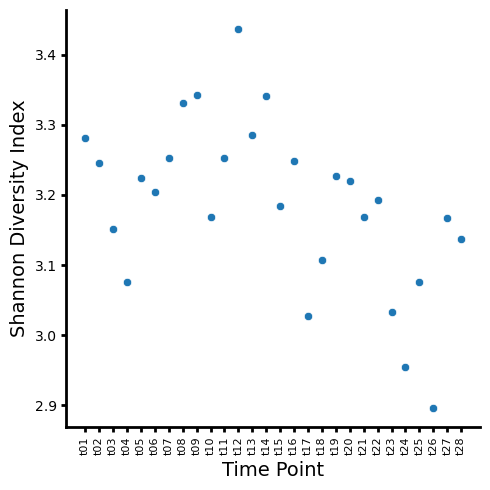

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(x=diversity_series.index, y=diversity_series)
plt.xlabel("Time Point", fontsize=14)
plt.ylabel("Shannon Diversity Index", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=10)
plt.tight_layout()

## Cross-check: per-sample Shannon

Per-sample Shannon values from `lic_16S_gen_shannon.csv`, grouped by timepoint. Each point is one sample and the black line is the timepoint mean. These values are the diversity *within* each sample, averaged over a timepoint. The plot above instead measures the diversity of the pooled, timepoint-averaged community, so it runs higher.

In [8]:
sample_shannon = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Sept_2026_recalled_genera/lic_16S_gen_shannon.csv"
)
sample_shannon = sample_shannon.merge(
    sample_timepoint.rename("timepoint"),
    left_on="sampleID",
    right_index=True,
)
print("samples matched:", len(sample_shannon), "/", len(sample_timepoint))

sample_shannon_by_timepoint = (
    sample_shannon.groupby("timepoint")["Shannon"].agg(["mean", "std", "count"])
)
sample_shannon_by_timepoint

samples matched: 222 / 222


,mean,std,count
timepoint,,,
t01,2.882149,0.340493,8
t02,2.838479,0.756324,8
t03,2.828654,0.313092,8
t04,2.697975,0.269217,8
t05,2.766773,0.563193,8
t06,2.872002,0.613529,8
t07,2.806579,0.424954,8
t08,2.985202,0.301663,8
t09,2.983069,0.204948,8


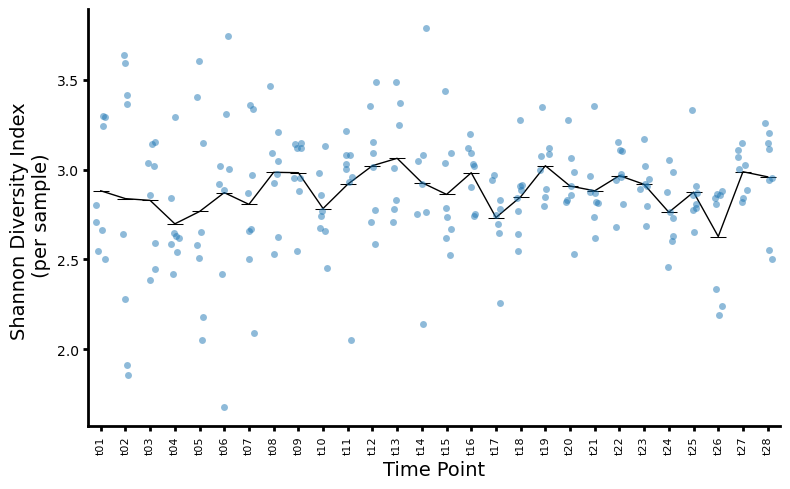

In [9]:
timepoint_order = sorted(sample_shannon["timepoint"].unique())

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
sns.stripplot(
    data=sample_shannon,
    x="timepoint",
    y="Shannon",
    order=timepoint_order,
    alpha=0.5,
    jitter=0.2,
    ax=ax,
)
sns.pointplot(
    data=sample_shannon,
    x="timepoint",
    y="Shannon",
    order=timepoint_order,
    estimator="mean",
    errorbar=None,
    color="black",
    markers="_",
    markersize=12,
    linewidth=1,
    ax=ax,
)
plt.xlabel("Time Point", fontsize=14)
plt.ylabel("Shannon Diversity Index \n (per sample)", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=10)
plt.tight_layout()

## Shannon diversity vs rain in the previous 24h

Replicates the double-y-axis figures from the plates 1–5 notebook. Hourly precipitation comes from meteostat at the same point and date range as the original. Rain in the previous 24h is a rolling 24h sum, carried forward to each sampling time.

In [10]:
import datetime as dt
import meteostat

start_time = dt.datetime(2023, 10, 1)
end_time = dt.datetime(2024, 4, 30)
luke_apt_point = meteostat.Point(40.73005, -73.99450)
luke_hourly_data = meteostat.Hourly(luke_apt_point, start_time, end_time).fetch()

rain_last_24h = luke_hourly_data["prcp"].fillna(0).sort_index().rolling("24h").sum()

# Sampling date/time for each timepoint, from the day and time columns
timepoint_datetimes = (
    long_term_microbiome.groupby("timepoint")[["day", "time"]]
    .first()
    .pipe(lambda df: pd.to_datetime(df["day"] + " " + df["time"], format="%m/%d/%y %H:%M"))
    .sort_values()
)

shannon_over_time = diversity_series.reindex(timepoint_datetimes.index)
shannon_over_time.index = pd.DatetimeIndex(timepoint_datetimes.values)
shannon_over_time = shannon_over_time.sort_index()

rain_last_24h_at_samples = (
    rain_last_24h.reindex(rain_last_24h.index.union(shannon_over_time.index))
    .sort_index()
    .ffill()
    .reindex(shannon_over_time.index)
)
rain_last_24h_at_samples

2023-11-01 08:00:00    0.7
2023-11-07 08:00:00    0.0
2023-11-14 08:00:00    0.4
2023-11-17 08:00:00    0.0
2023-11-21 08:00:00    0.0
2023-11-28 08:00:00    0.0
2023-12-01 08:00:00    0.0
2023-12-05 08:00:00    0.0
2023-12-08 08:00:00    0.0
2023-12-12 08:00:00    4.7
2023-12-15 08:00:00    0.0
2024-01-05 08:00:00    0.0
2024-01-15 08:00:00    0.2
2024-01-23 08:00:00    0.0
2024-01-27 08:00:00    3.8
2024-01-30 08:00:00    0.5
2024-02-02 08:00:00    1.8
2024-02-06 08:00:00    0.0
2024-02-09 08:00:00    0.2
2024-02-16 08:00:00    1.1
2024-02-20 08:00:00    0.0
2024-02-23 08:00:00    3.8
2024-02-26 08:00:00    0.0
2024-03-01 08:00:00    0.0
2024-03-05 08:00:00    0.0
2024-03-08 08:00:00    1.3
2024-03-12 08:00:00    0.0
2024-03-14 08:00:00    0.0
Name: prcp, dtype: float64

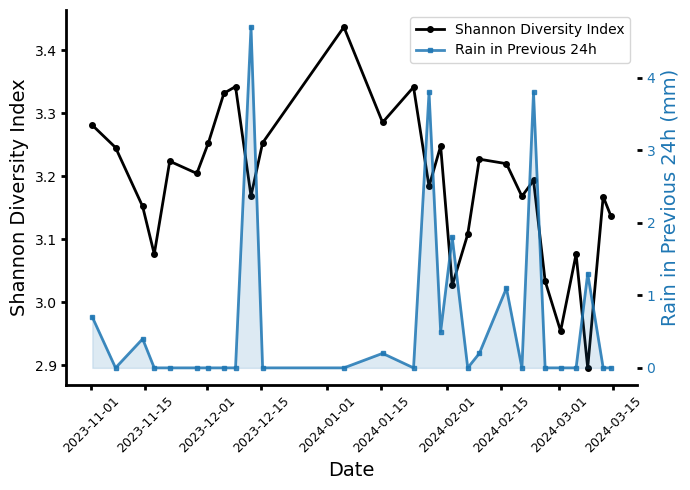

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.plot(
    shannon_over_time.index,
    shannon_over_time.values,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Shannon Diversity Index",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Shannon Diversity Index", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    rain_last_24h_at_samples.index,
    rain_last_24h_at_samples.values,
    color="tab:blue",
    linewidth=2,
    marker="s",
    markersize=3.5,
    alpha=0.85,
    label="Rain in Previous 24h",
)
ax_rain.fill_between(
    rain_last_24h_at_samples.index,
    0,
    rain_last_24h_at_samples.values,
    color="tab:blue",
    alpha=0.15,
)
ax_rain.set_ylabel("Rain in Previous 24h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper right")
plt.tight_layout()

### Per-sample version

Uses the same per-sample Shannon values as the cross-check above. The line is the per-sample mean at each timepoint with a bootstrapped 95% CI, and each sample is drawn as a faint point.

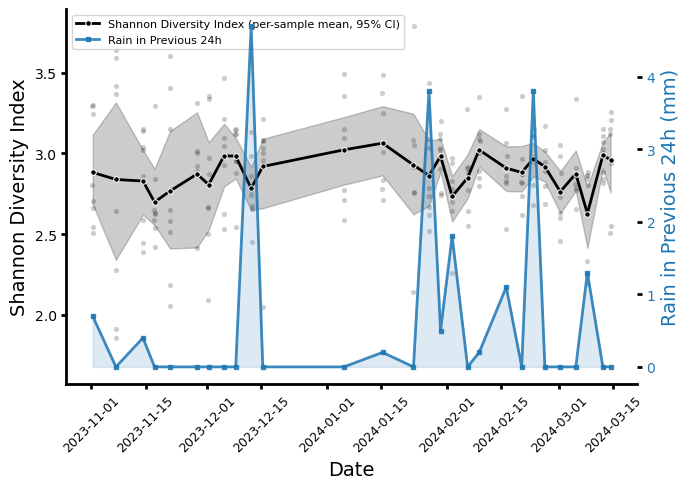

In [12]:
per_sample_shannon_df = sample_shannon.assign(
    **{"Date and Time": sample_shannon["timepoint"].map(timepoint_datetimes)}
).sort_values("Date and Time")

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
jitter_rng = np.random.default_rng(0)
jittered_sample_times = per_sample_shannon_df["Date and Time"] + pd.to_timedelta(
    jitter_rng.uniform(-2.5, 2.5, len(per_sample_shannon_df)), unit="h"
)
ax.scatter(
    jittered_sample_times,
    per_sample_shannon_df["Shannon"],
    color="black",
    alpha=0.2,
    s=14,
    linewidths=0,
    zorder=1,
)
sns.lineplot(
    data=per_sample_shannon_df,
    x="Date and Time",
    y="Shannon",
    ax=ax,
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    errorbar=("ci", 95),
    err_style="band",
    label="Shannon Diversity Index (per-sample mean, 95% CI)",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Shannon Diversity Index", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    rain_last_24h_at_samples.index,
    rain_last_24h_at_samples.values,
    color="tab:blue",
    linewidth=2,
    marker="s",
    markersize=3.5,
    alpha=0.85,
    label="Rain in Previous 24h",
)
ax_rain.fill_between(
    rain_last_24h_at_samples.index,
    0,
    rain_last_24h_at_samples.values,
    color="tab:blue",
    alpha=0.15,
)
ax_rain.set_ylabel("Rain in Previous 24h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(
    lines_left + lines_right, labels_left + labels_right, loc="upper left", fontsize=8
)
plt.tight_layout()

In [13]:
# Spearman correlation of Shannon diversity with rain in the previous 24h
rho, p_value = spearmanr(rain_last_24h_at_samples.values, shannon_over_time.values)
print(f"Timepoint-level Shannon vs rain (n={len(shannon_over_time)}): rho = {rho:.3f}, p = {p_value:.3g}")

per_sample_rain = per_sample_shannon_df["Date and Time"].map(rain_last_24h_at_samples)
rho, p_value = spearmanr(per_sample_rain, per_sample_shannon_df["Shannon"])
print(f"Per-sample Shannon vs rain (n={len(per_sample_shannon_df)}): rho = {rho:.3f}, p = {p_value:.3g}")

Timepoint-level Shannon vs rain (n=28): rho = -0.131, p = 0.505
Per-sample Shannon vs rain (n=222): rho = -0.068, p = 0.31
